# Inspect Time Series Data

Author: Pete King

This notebook reads the data gathered from the FRED API and Yahoo Finance into Pandas and inspects each time series -- a simple exercise in getting more familiar with the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt


Lets inspect the data we pulled from Yahoo Finance

In [2]:
yfi_df = pd.read_csv('yfinance_data.csv', index_col='date')
yfi_df.head()

,BIL,BND,GLD,HYG_x,IEF,IWM,LQD_x,QQQ,SPY,TIP,...,NG=F,SHY,TLT_y,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
1927-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.660000,NaN,NaN,NaN,NaN,NaN
1928-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.760000,NaN,NaN,NaN,NaN,NaN
1928-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.719999,NaN,NaN,NaN,NaN,NaN
1928-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.549999,NaN,NaN,NaN,NaN,NaN
1928-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.660000,NaN,NaN,NaN,NaN,NaN


In [3]:
yfi_df.tail()

,BIL,BND,GLD,HYG_x,IEF,IWM,LQD_x,QQQ,SPY,TIP,...,NG=F,SHY,TLT_y,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
2026-03-05,91.419998,74.339996,466.130005,80.080002,96.510002,256.760010,110.529999,608.909973,681.309998,111.220001,...,3.003,82.690002,88.790001,10413.900391,6830.709961,25321.339844,74.529999,4.146,23.75,26.000000
2026-03-06,91.440002,74.239998,473.510010,79.690002,96.449997,250.889999,110.160004,599.750000,672.380005,111.430000,...,3.186,82.730003,88.459999,10284.799805,6740.020020,25757.289062,81.260002,4.133,29.49,31.440001
2026-03-09,91.449997,74.449997,472.529999,80.169998,96.750000,253.619995,110.820000,607.760010,678.270020,111.610001,...,3.120,82.769997,89.230003,10249.500000,6795.990234,25408.460938,79.739998,4.136,25.50,27.690001
2026-03-10,91.459999,74.220001,477.859985,80.040001,96.440002,253.360001,110.059998,607.770020,677.179993,111.239998,...,3.020,82.720001,88.279999,10412.200195,6781.479980,25959.900391,76.333199,4.136,24.93,27.330000
2026-03-11,91.461502,73.934998,474.839996,79.885002,96.065002,251.470001,109.269997,606.719971,674.653503,111.114998,...,3.146,82.654999,87.334999,10341.830078,6758.709961,25898.759766,NaN,4.206,24.91,27.049999


We can see visually roughly how far our data goes back for each series by looking for missing values (shown as white gaps in the image below).

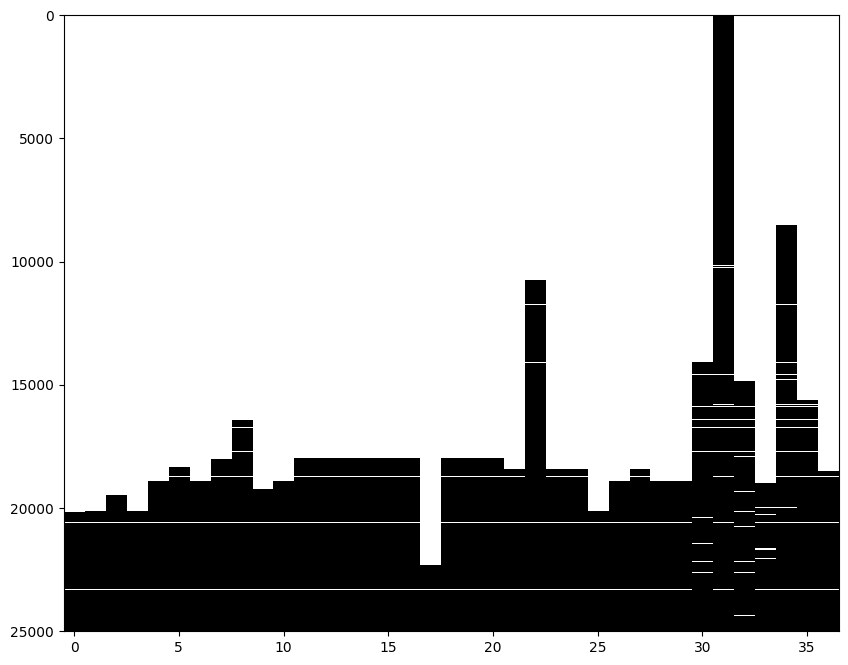

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.subplots()

ax.imshow(yfi_df.isna(), aspect="auto", interpolation="nearest", cmap="gray")

In [5]:
for col_name in yfi_df.columns:
    print(yfi_df[col_name].dropna().head(1))

date
2007-05-30    71.63269
Name: BIL, dtype: float64
date
2007-04-10    41.776531
Name: BND, dtype: float64
date
2004-11-18    44.380001
Name: GLD, dtype: float64
date
2007-04-11    32.336353
Name: HYG_x, dtype: float64
date
2002-07-30    41.094494
Name: IEF, dtype: float64
date
2000-05-26    32.726269
Name: IWM, dtype: float64
date
2002-07-30    37.394123
Name: LQD_x, dtype: float64
date
1999-03-10    43.128651
Name: QQQ, dtype: float64
date
1993-01-29    24.241398
Name: SPY, dtype: float64
date
2003-12-05    51.016987
Name: TIP, dtype: float64
date
2002-07-30    36.526863
Name: TLT_x, dtype: float64
date
1998-12-22    5.743472
Name: XLB, dtype: float64
date
1998-12-22    5.77411
Name: XLE, dtype: float64
date
1998-12-22    11.220843
Name: XLF, dtype: float64
date
1998-12-22    14.472648
Name: XLI, dtype: float64
date
1998-12-22    11.93813
Name: XLK, dtype: float64
date
1998-12-22    14.064749
Name: XLP, dtype: float64
date
2015-10-08    21.185568
Name: XLRE, dtype: float64
date
199

Most of the ETFs go back to at least 2002, except for XLRE which starts in 2015.  Dropping XLRE will give us a much longer history to work with.

Now lets take a look at the data we pulled from the FRED API.

In [6]:
fred_df = pd.read_csv('fred_data.csv', index_col='date')
fred_df.head()

,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,unemployment_rate,...,female_unemployment_rate,average_duration_of_unemployment,one_month_yield,three_month_yield,six_month_yield,one_year_yield,two_year_yield,five_year_yield,ten_year_yield,thirty_year_yield
date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-01-01,243.164,2182.681,NaN,5.352,21.48,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
fred_df.tail()

,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,unemployment_rate,...,female_unemployment_rate,average_duration_of_unemployment,one_month_yield,three_month_yield,six_month_yield,one_year_yield,two_year_yield,five_year_yield,ten_year_yield,thirty_year_yield
date,,,,,,,,,,,,,,,,,,,,,
2026-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.75,3.71,3.68,3.55,3.51,3.63,4.06,4.70
2026-03-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.75,3.71,3.68,3.58,3.54,3.67,4.09,4.72
2026-03-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.75,3.70,3.68,3.59,3.57,3.72,4.13,4.74
2026-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.75,3.69,3.66,3.55,3.56,3.72,4.15,4.77
2026-03-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.75,3.71,3.68,3.56,3.56,3.71,4.12,4.72


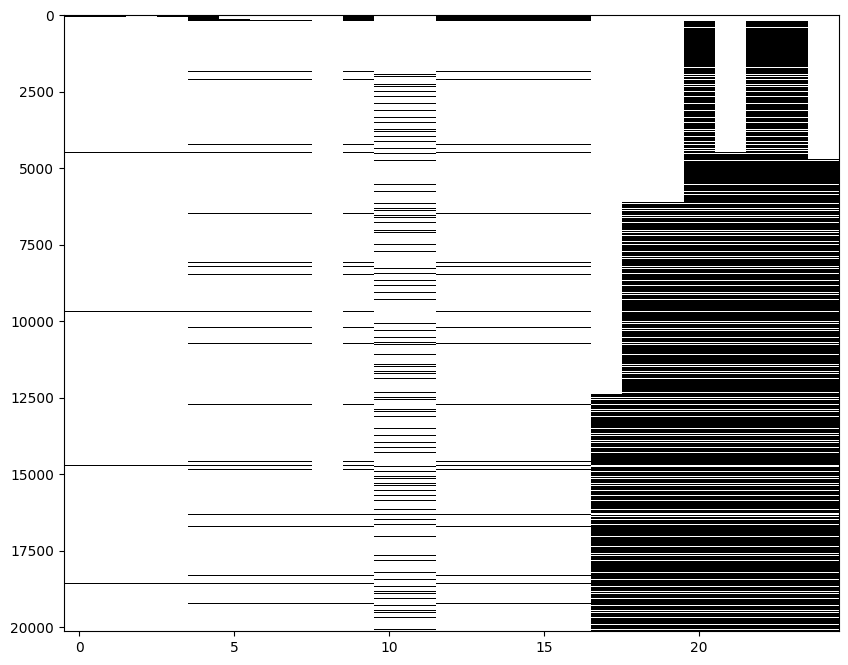

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.subplots()

ax.imshow(fred_df.isna(), aspect="auto", interpolation="nearest", cmap="gray")

In [9]:
for col_name in fred_df.columns:
    print(fred_df[col_name].dropna().head(1))

date
1947-01-01    243.164
Name: nominal_GDP, dtype: float64
date
1947-01-01    2182.681
Name: real_GDP, dtype: float64
date
1966-01-01    40.33999
Name: debt_to_GDP, dtype: float64
date
1947-01-01    5.352
Name: debt_interest, dtype: float64
date
1947-01-01    21.48
Name: consumer_price_index, dtype: float64
date
1957-01-01    28.5
Name: core_PCI, dtype: float64
date
1959-01-01    15.164
Name: personal_consumption_expenditure, dtype: float64
date
1959-01-01    15.501
Name: core_PCE, dtype: float64
date
2009-11-01    100.2
Name: producer_price_index, dtype: float64
date
1948-01-01    3.4
Name: unemployment_rate, dtype: float64
date
1967-01-07    208000.0
Name: initial_jobless_claims, dtype: float64
date
1967-01-07    1134000.0
Name: continued_jobless_claims, dtype: float64
date
1948-01-01    8.5
Name: teenager_unemployment_rate, dtype: float64
date
1948-01-01    3.0
Name: adult_unemployment_rate, dtype: float64
date
1948-01-01    3.4
Name: male_unemployment_rate, dtype: float64
date
19

This data goes back quite a lot further, but here we have different frequency time series (quarterly, monthly, weekly, and daily).  The result is an overall sparse dataset for most of the time series.  The easy option would be to forward-fill the missing data.  The MIxed DAta Sampling (MIDAS) technique from econometrics presents an alternate way to deal with mixed frequency data, but implementation may be complicated.